# Flask Foundations — Friendly Notes 🧸

These notes turn the lesson transcripts into a tiny, practical guide. Think of Flask as a small helper that lets Python answer when someone visits a web page.

**You will learn:** what Flask does, how a request travels, routes, HTML templates, Jinja, and the difference between GET and POST.

## 1. What is Flask?

A **web framework** is a box of helpful tools for building websites with code. **Flask** is a lightweight web framework written in Python.

Imagine a small restaurant:

- A visitor asks for something (a **request**).
- Flask reads the request, asks Python what to do, and prepares an answer.
- The visitor receives the answer (a **response**).

For a machine-learning project, Flask can show a form where a person enters values or uploads an image. Python can send those values to an ML model and show the prediction on a web page.

## 2. The big picture

```text
Browser (person) → web server → Flask app → Python / database / ML model
Browser (person) ← web server ← Flask app ← result
```

A **web server** is the home where a deployed web app runs. It may be on a cloud service such as AWS, Azure, or Google Cloud. While learning, Flask's development server runs on your own computer at `localhost`.

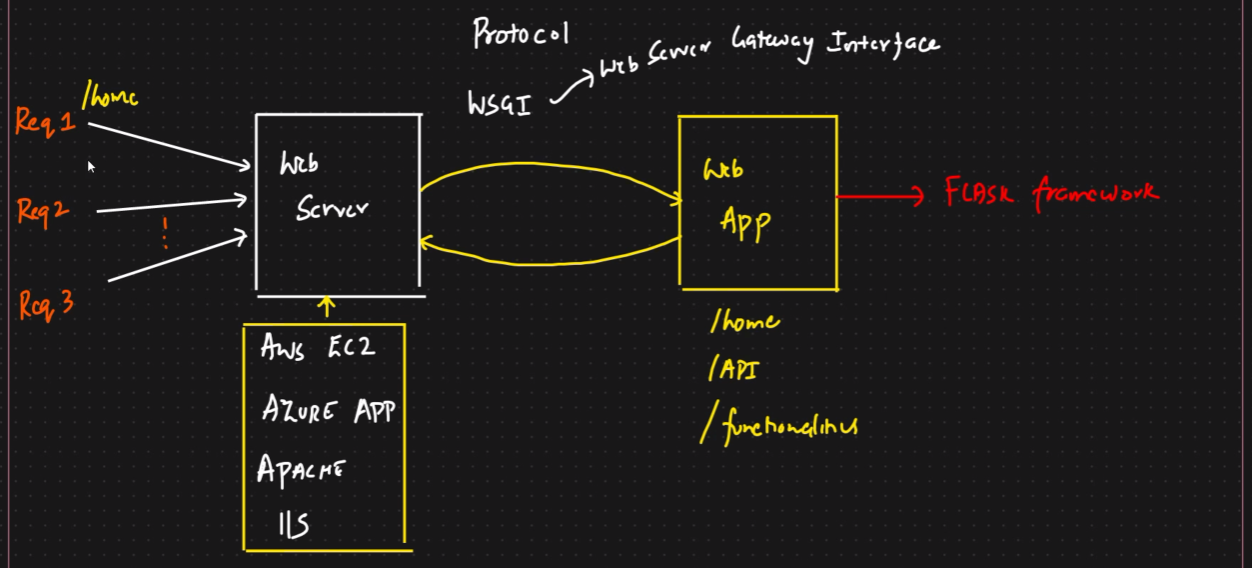

## 3. WSGI: the translator

**WSGI** means **Web Server Gateway Interface**. It is a Python standard that describes how a web server and a Python web application talk to each other.

Think of it as a translator between two friends who speak different languages:

1. The server receives a browser request.
2. Using the WSGI agreement, it passes the request to the Flask app.
3. Flask creates a response.
4. The server sends that response back to the browser.

You usually do **not** write WSGI code for a beginner Flask app. It becomes more visible when deploying an app.

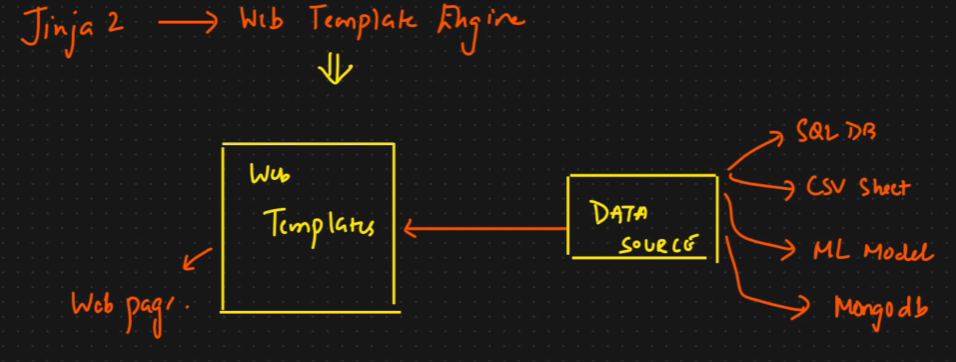

## 4. Install Flask

Run this once in a terminal (preferably inside a virtual environment):

```bash
pip install flask
```

Then save the next Python example as `app.py` and run `python app.py`. Open the address printed in the terminal, usually `http://127.0.0.1:5000/`.

## 5. Your first Flask app

A **route** is like a labelled door. `/` is the home door; `/about` is another door. When somebody visits a door, Flask runs the function directly below its `@app.route(...)` label.

In [ ]:
from flask import Flask

app = Flask(__name__)  # make our Flask application

@app.route('/')
def home():
    return 'Hello! This is the home page.'

@app.route('/about')
def about():
    return 'This is the about page.'

if __name__ == '__main__':
    app.run(debug=True)

### What each important piece means

- `Flask(__name__)` creates the app.
- `@app.route('/')` connects a URL to a function.
- `return ...` is the response sent to the browser.
- `debug=True` restarts the development server after code changes and shows useful errors. Use it only while developing — not on a public production site.
- Every route path should be unique.

## 6. Why HTML templates?

You *can* return HTML directly from a route, such as `return '<h1>Hello</h1>'`. That is okay for a tiny experiment, but it gets messy quickly.

A cleaner idea is to keep the page in its own HTML file. Flask looks for those files inside a folder named exactly **`templates`**.

```text
my_project/
├── app.py
└── templates/
    ├── index.html
    └── about.html
```

In [ ]:
from flask import Flask, render_template

app = Flask(__name__)

@app.route('/')
def home():
    return render_template('index.html')

@app.route('/about')
def about():
    return render_template('about.html')

Example `templates/index.html`:

```html
<!doctype html>
<html>
  <body>
    <h1>Welcome to my Flask app!</h1>
    <p>This page lives in a separate HTML file.</p>
  </body>
</html>
```

`render_template('index.html')` tells Flask: “Please find `index.html` in `templates` and send it to the browser.” If the file is missing or in the wrong folder, Flask raises `TemplateNotFound`.

## 7. Jinja: putting changing data into a page

**Jinja** (often called Jinja2) is Flask's template engine. A template engine mixes a page layout with data to make a **dynamic page**.

For example, the data might come from a database, CSV file, API, or ML model. In a template, `{{ name }}` means: “put the value of `name` here.”

In [ ]:
@app.route('/hello/<name>')
def hello(name):
    return render_template('greeting.html', name=name)

Example `templates/greeting.html`:

```html
<h1>Hello, {{ name }}!</h1>
<p>Flask filled in the name for us.</p>
```

Visiting `/hello/Ada` displays **Hello, Ada!**

## 8. HTTP methods: GET and POST

A route needs to know *what kind* of request arrived. The two first methods to learn are:

| Method | Little-kid version | Typical use |
| --- | --- | --- |
| **GET** | “Please show me something.” | Open a page, read/search data. |
| **POST** | “Here is information for you.” | Submit a form, create/send data. |

Important correction: a web search is commonly a **GET** request with its query in the URL. A POST request is normally used when a form sends data in the request body. GET is the default method for a Flask route. Other common methods are `PUT` (update) and `DELETE` (remove).

## 9. A small form that handles GET *and* POST

When the browser first opens `/form`, it makes a GET request and receives the form. When the person presses **Submit**, the form makes a POST request. `request.form.get('name')` safely reads the form field named `name`.

In [ ]:
from flask import Flask, render_template, request

app = Flask(__name__)

@app.route('/form', methods=['GET', 'POST'])
def form():
    if request.method == 'POST':
        name = request.form.get('name', '').strip()
        if not name:
            return 'Please type your name.', 400
        return render_template('greeting.html', name=name)

    return render_template('form.html')

Example `templates/form.html`:

```html
<form method="post">
  <label for="name">Your name:</label>
  <input id="name" name="name" type="text" required>
  <button type="submit">Say hello</button>
</form>
```

The field needs a **`name` attribute** because `request.form.get('name')` uses that name. An `id` is useful for matching a label, but it is not what Flask uses to read submitted form data.

## 10. Tiny recap

1. Flask lets Python build web applications.
2. A route connects a URL to Python code.
3. WSGI is the server-to-Python-app communication agreement.
4. Put HTML files in `templates/` and use `render_template`.
5. Jinja puts changing Python data into HTML with `{{ variable }}`.
6. Use GET to show/read things and POST to submit data.

### Try it yourself

Make a `/favorite-color` form. After submission, render a template that says: `Your favorite color is {{ color }}`.